# Project 1. Dimension Reduction Using SVD and PCA
##              Due: Wednesday, April 30, 11:59pm

### Student ID: 921914042
### Student Name: Arezoo Ghasemzadeh

## Part I: Methodology --> UPLOAD THE PICTURE

Write the answer to the following questions on a sheet of paper (you can also use LATEX) and upload a scanned copy of your answers to gradescope. Make sure that your answers are readable (i.e write legibly and scan the entire page). 

### Problem 1: 

Suppose the matrix $A$ is $(n \times m$). 
1. Consider the singular value decomposition of $A$ of the form
$$A = U \Sigma V^\top.$$
Describe the three matrices on the right by listing their dimensions and other properties.
2. Consider the matrix $A^\top A.$  
    - Why is $A^\top A$ a PSD matrix? (Show it.) 
    - Use the SVD of $A$ from above to find the eigendecomposition of $A^\top A.$
    - How are the eigenvalues of $A^\top A$ related to the singular values of $A$.
3. Consider the matrix $AA^\top$ and answer the questions from the previous part by replacing $A^\top A$ through $AA^\top$
4. How are the ranks of $A$, $A^\top A$ and $AA^\top$ related, and how can one use the above to verify your answer?

## Part II: Data Analysis

In [104]:
# All Import Statements Defined Here
# Note: Do not change anything

import numpy as np
from typing import List
import math
import matplotlib.pyplot as plt
from matplotlib.image import imread

from numpy.linalg import svd
from sklearn.decomposition import PCA
import os
from sklearn.datasets import load_digits

%matplotlib inline

## Part 1. SVD Image Compression

### Load Data (do not change the code !)

In [105]:
## image1 should be lake.png, which is contained in the project zip file
## image2 should be one of your own color photos in png format that you like 

# image1 = imread(os.getcwd()+'lake.png')

image1 = imread('/Users/arezoog/Desktop/Spring 2026/STA142B/HW1/lake.png')

#image2 =  imread(os.getcwd()+'/photo.png')

image2 = imread('/Users/arezoog/Desktop/Spring 2026/STA142B/HW1/goat.png')

image1 = image1[:,:,:3]
image2 = image2[:,:,:3]

## store the images in image_dict with name lake for image1 and name photo for image2

image_dict = {'lake':image1,'goat':image2}

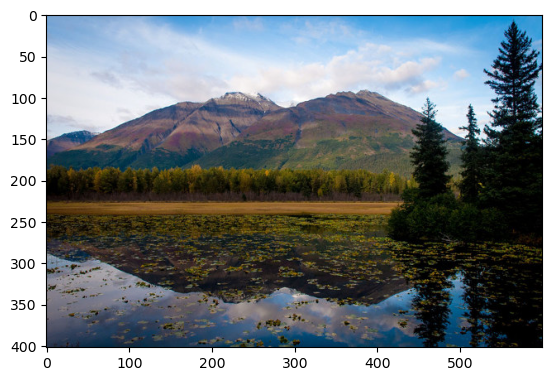

In [106]:
plt.imshow(image_dict['lake'])

In [107]:
image_dict['lake'].shape
## See below for explanation of the dimensions

(402, 600, 3)

So one can think of a digital image as consisting of three layers (one for red (R), one for green (G), and one for blue (B)), and each layer is a matrix (here of size 402 x 600). One can also think of a 3-d matrix, where here the size of the third dimension is very small (only three) as compared to the other two sizes (402 and 600).

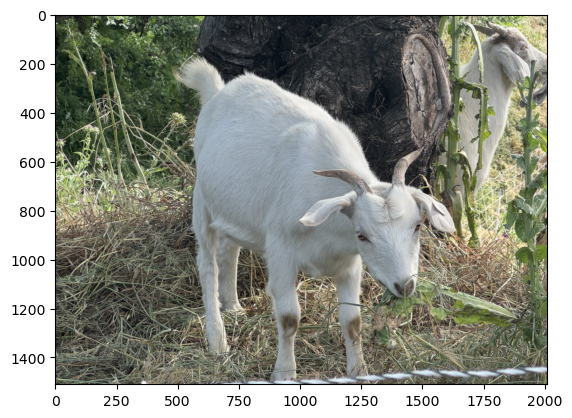

In [108]:
plt.imshow(image_dict['goat'])
#put your own photo here

<font color='red'>Add a bit of introduction to yourself here, like your name, major, year, background, interests or any fun things you want to talk about.</font>

Hi! My name is Arezoo and I am a third year Statistics major with a minor in Psychology and Neuroscience.

I am part of the UC Davis triathlon club but enjoy running the most and biking (when with friends :D). In my free time, I like to make music playlist across different genres, go on walks, and talk to the animals (specifically goats, squirrels, and cats). I also like to surf when back in the Bay.

### Write a function to get the compressed matrix

SVD can be used to find lower rank approximations of matrices by setting (small) singular values to zero. More specifically, if $X = s_1u_1v_1^\top＋\ldots+s_du_dv_d^\top$ is the SVD of a matrix (think image), where the singular values $s_k$ are sorted by size $(s_1 \ge s_2 \ge \cdots)$, then we can truncate this sum and use ${\tilde X}_k = s_1u_1v_1^\top＋\ldots+s_ku_kv_k^\top$ with $k<d$ to approximate $X$. Note that the approximation ${\tilde X}_k$ has an SVD with $k$ (non-zero) singular values, and thus the rank of this matrix is $k$ (which is smaller than $d$). This approximation matrix is used as the compressed matrix. This indeed is a compressed matrix, because we only need to store the $k$ vectors $u_1,\ldots,u_k$, the $k$ vectors $v_1,\ldots,v_k$ and the first $k$ singular values, which are $k(1+n+m)$ values as compared to storing the entire matrix. Storing the entire matrix can be done by storing all the elements of the entire SVD, which are $d(1+n+m)$ values, or the original pixels, which are $nm$ values, depending what is smaller. (Note that if $n=m$, then all the pixels are $n^2$ values, while storing the SVD means storing $(2n+1)d \approx 2nd$ values. Thus if the rank $d$ of the matrix is (close to) $n$, then we do not gain anything when storing the SVD, but if $d$ is much less than $n$ (or when compressing the matrix with only using $k$ summands in the SVD with $k$ much less than $n$), then we can gain a lot. Of course, when compressing a matrix (image), we need to make sure that we do not loose too much information, and this is related to the size of the 'small' singular values that are being omitted when doing the compression (see 'reconstruction error' below).

Now, write a function to implement this compression of the images.

Recommended functions: svd

 Notes_Steps Conceptually:

* Run SVD on the input matrix --> give you U, S, Vt
* Keep only the first k singular values 
* Reconstruct the matrix using only those k values 
* Return the reconstructed matrix 

In [109]:
import numpy as np
from typing import List

def compress_svd(matrix: List[List[int]], k: int) -> List[List[int]]:
    
    # Convert input list to nump array of floats (SVD requires float values)
    matrix = np.array(matrix, dtype=float)

    # Decompose matrix into U (left vectors), S (singular values), Vt (right vectors transposed)
    # S is already sorted largest to smallest 
    U, S, Vt = np.linalg.svd(matrix, full_matrices=False)

    k = min(k, len(S))

    # Start with an empty matrix of zeros, same shape as original
    compressed_matrix = np.zeros_like(matrix)

    # Add up the first k rank-1 pieces: each piece = si * ui * vi^T
    for i in range(k):
        # S[i] = i-th singular value, U[:,i] = i-th left vector, Vt[i,:] i-th right vector 
        compressed_matrix += S[i] * np.outer(U[:, i], Vt[i, :])

    return compressed_matrix

### Write the following functions to compress the images in two different ways

Each image file has three channels "red", "green" and "blue","RGB", which corresponds to image[:,:,0], image[:,:,1], and image[:,:,2]. The values in image[i,j,0], for instance, are the intensities of the red channel at location (i,j). Now, you need to write two different functions
- "compress_show_images_reshape" to perform compression by combining the three channels together to a bigger matrix and then decomposing it back to three channels so that it can be displayed as an image again;
- "compress_show_images_separate" to perform compressions on three channels separately.

Reconstruction error is defined as the mean squared error, i.e., the mean (average) of the squared differences between the entries in the original image tensor and the entries in the compressed image tensor. So if your image tensor has shape (I,J,3), then the sum in the recostruction error extends over all I * J * 3 squared differences.

Recommended functions: imshow, compress_svd

Notes_Functions_Explanations:

* np.dstack( ): used to rebuild the color image from the three compressed channels
* np.clip( ): used to keep the reconstructed pixel values in the valid display range 

In [110]:
def compress_show_images_reshape(image_name: str, k: int, show_image=True):
    """
    image_name (string): image name in the image_dict;
    k (int): number of singular values used for image compression;
    show_image (boolean): whether to plot the compressed images or not;

    Concatenate the first three layers of the image tensor into one wide matrix;
    Use compress_svd function to perform svd compression;
    Reshape the wide compressed matrix into an image tensor of three layers;
    If show_image is true, plot the compressed image;
    Put the number of singular values and reconstruction error in the title;

    return reconst_error (float), which is the mean squared error of the compressed image
    """

    image = image_dict[image_name]
    I, J, C = image.shape

    wide_matrix = np.hstack((image[:, :, 0], image[:, :, 1], image[:, :, 2]))
    compressed_wide = compress_svd(wide_matrix, k)

    compressed_image = np.dstack((
        compressed_wide[:, 0:J],
        compressed_wide[:, J:2*J],
        compressed_wide[:, 2*J:3*J]
    ))
    compressed_image = np.clip(compressed_image, 0, 1)

    reconst_error = np.mean((image - compressed_image) ** 2)

    if show_image:
        plt.imshow(compressed_image)
        plt.title(f"{image_name}, k = {k}, reconstruction error = {reconst_error:.6f}")
        plt.axis('off')

    return reconst_error

In [111]:
def compress_show_images_separate(image_name: str, k: int, show_image=True):
    """
    image_name (string): image name in the image_dict;
    k (int): number of singular values used for image compression;
    show_image (boolean): whether to plot the compressed images or not;

    Use compress_svd function to perform svd compression for each of the three layers of the image tensor separately;
    If show_image is true, plot the compressed image;
    Put the number of singular values and reconstruction error in the title;

    return reconst_error (float), which is the mean squared error of the compressed image
    """

    image = image_dict[image_name]

    red_compressed = compress_svd(image[:, :, 0], k)
    green_compressed = compress_svd(image[:, :, 1], k)
    blue_compressed = compress_svd(image[:, :, 2], k)

    compressed_image = np.dstack((red_compressed, green_compressed, blue_compressed))
    compressed_image = np.clip(compressed_image, 0, 1)

    reconst_error = np.mean((image - compressed_image) ** 2)

    if show_image:
        plt.imshow(compressed_image)
        plt.title(f"{image_name}, k = {k}, reconstruction error = {reconst_error:.6f}")
        plt.axis('off')

    return reconst_error

np.float64(0.0021455916701113653)

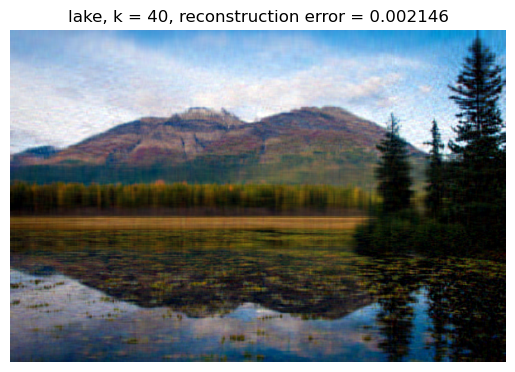

In [112]:
compress_show_images_separate('lake',40)

np.float64(0.002552586777804943)

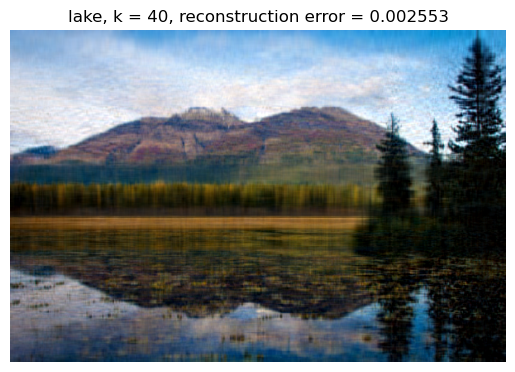

In [113]:
compress_show_images_reshape('lake',40)

### Write a function to plot the reconstruction errors and their differences

Compare and visualize the reconstruction errors (see above). Recommended functions to use: matplotlib.pyplot, subplot.

In [114]:
def plot_error(image_name: str, k_min: int, k_max: int):
    """
    image_name (string): image name in the image_dict ;
    k_min (int): minimum number of singular values used for image compression;
    k_max (int): maximum number of singular values used for image compression;

    Plot the reconstruction errors using k ranging from k_min to k_max;
    Use a blue line to indicate the reconstruction error using compress_show_images_reshape function;
    Use an orange line to indicate the reconstruction error using compress_show_images_separate function;
    In a separate subfigure, plot the difference of the reconstruction errors for each k between k_min and k_max
    """

    k_values = list(range(k_min, k_max + 1))
    reshape_errors = []
    separate_errors = []

    for k in k_values:
        err_reshape = compress_show_images_reshape(image_name, k, show_image=False)
        err_separate = compress_show_images_separate(image_name, k, show_image=False)

        reshape_errors.append(err_reshape)
        separate_errors.append(err_separate)

    differences = [reshape_errors[i] - separate_errors[i] for i in range(len(k_values))]

    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.plot(k_values, reshape_errors, color='blue', label='reshape')
    plt.plot(k_values, separate_errors, color='orange', label='separate')
    plt.xlabel('k')
    plt.ylabel('Reconstruction Error')
    plt.title(f'Reconstruction Errors for {image_name}')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(k_values, differences, color='purple')
    plt.axhline(0, color='black', linestyle='--', linewidth=1)
    plt.xlabel('k')
    plt.ylabel('Error Difference')
    plt.title('Reshape Error - Separate Error')

    plt.tight_layout()
    plt.show()

Make some exploratory plots (do not include it in your final submission). Describe briefly what you find (is one error always smaller than the other? is the difference monotonic?)

In [115]:
#plot_error('lake', 1, 20)

Answers:

For the lake image, the seperate-channel compression consistently gives smaller reconstruction error than the reshape method for all tested value of k. The difference between the two methods is not strictly monotic at the start because it increases slightly from k = 1 to k = 2, but after that it decreases gradully and then levels off as k gets largers. 

## <font color="Red"> Run the following code.</font> (do not change the code!)

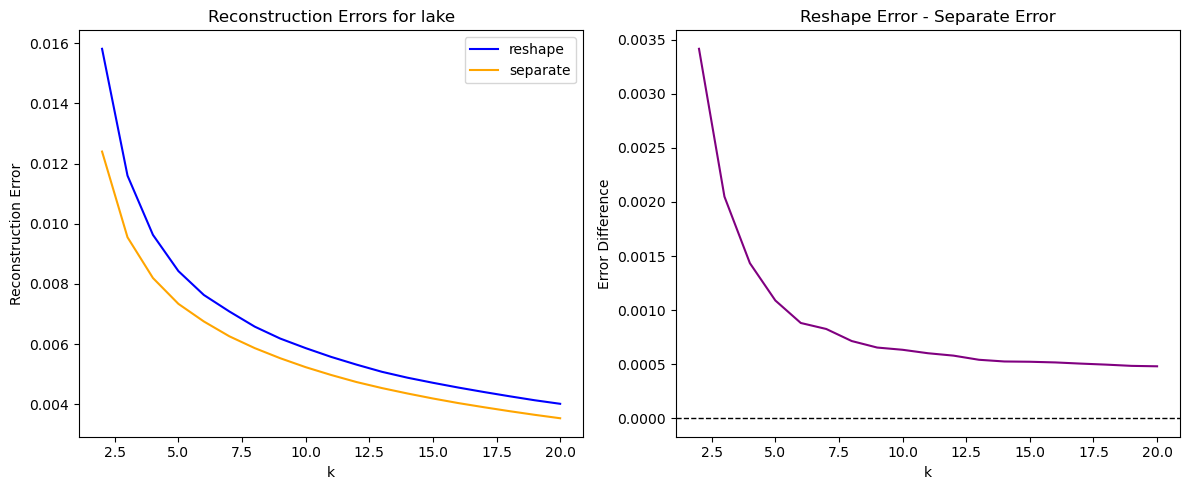

In [116]:
plot_error('lake',2,20)

In [117]:
[compress_show_images_separate('lake',k,False) for k in [1,5,10,20,30,40,20000]]

[np.float64(0.018205947777298143),
 np.float64(0.007337881796147045),
 np.float64(0.005232826590113411),
 np.float64(0.0035341607323361615),
 np.float64(0.0026961110021455612),
 np.float64(0.0021455916701113653),
 np.float64(2.1695648947718275e-30)]

In [118]:
[compress_show_images_reshape('lake',k,False) for k in [1,5,10,20,30,40,20000]]

[np.float64(0.021387123445243985),
 np.float64(0.008426885060008566),
 np.float64(0.005866005450164315),
 np.float64(0.004014562479821763),
 np.float64(0.003147012424096169),
 np.float64(0.002552586777804943),
 np.float64(9.087396488225136e-30)]

In [119]:
from ipywidgets import interact

interactive(children=(Dropdown(description='image_name', options=('lake', 'photo'), value='lake'), IntSlider(v…

<function __main__.compress_show_images_reshape(image_name: str, k: int, show_image=True)>

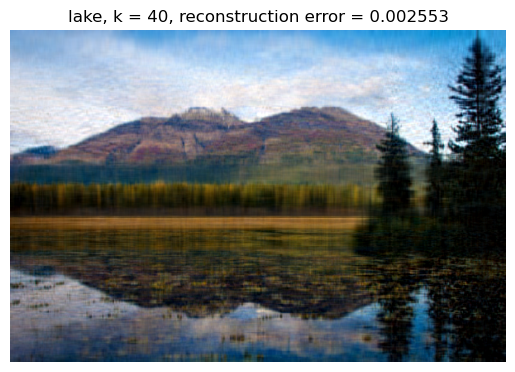

In [120]:
interact(compress_show_images_reshape,image_name=['lake','photo'], k=(10,70))

## Part 2. PCA of hand-written digits

### Load data

The data we are going to work with are hand-writted digits data. The digits data available in sklearn consists of 1797 images of handwritten digits, each image consisting of  8×8=64  pixels. We can think of the digits to consist of 10 classes (one class for each of the digits 0 - 9). Indeed, the data set comes with labels 0-9, indicating the figure it represents ("digits.target" gives you these labels as an array), although when performaing PCA we are ignoring the labels ("unsupervised"). We only use the labels to make vizualising the results more effective. In the following code, change the value of the index to plot different images.

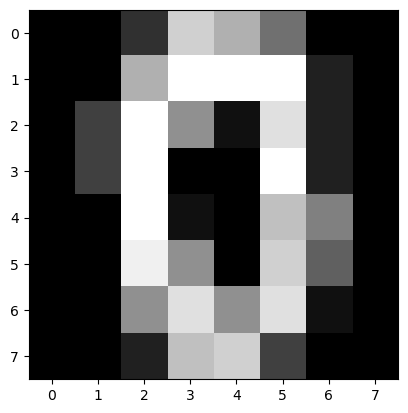

In [121]:
index = 20
digits = load_digits()
plt.imshow(digits.images[index],cmap='gray')
# target = digits.target

In [122]:
# To see the size of the data set

digits.data.shape

(1797, 64)

### Check the covariance matrix

Notice that in contrast to the first part of this project, we here have many images, and we consider each image as a data point. To this end we consider each image, i.e. each $(8 \times 8)$-matrix representing the image, as a vector (a 'stringed' matrix) of length $8 \times 8 = 64$. So our data are now 64-dimensional vectors, and we have 1797 such data points.

The following code computes the covariance matrix of these data vectors and gets its rank.

In [123]:
mu=digits.data.mean(axis=0)
X=digits.data
X_bar=np.repeat(mu,X.shape[0]).reshape(len(mu),-1).T
cov=np.dot( (X-X_bar).T, X-X_bar )

np.linalg.matrix_rank(cov)


np.int64(61)

So, in the above code, X is our $(1797 \times 64)$ data matrix, where each row is one of the images considered as a $64$-dimensional vector. X_bar is the 64-dimensional vector of averages (taken over the 1797 vectors) of each of the components of the vector, so that np.cdot(X-X_bar.T X-X_bar) is the covariance matrix of our 64-dimensional data cloud. Interpret what you have found above.

The data matrix has shape (1797, 62) meaning there are 1797 digit images and each image is represented as a 6t4-dimensional vector because each 8x8 image has 64 pixels. The covariance matrix has rank 61, so the 64 features are not all linearly independent. This means the digit data effectively lie in a lower-dimensional subspace, with only 61 independent directions of variation.

### Apply PCA to the image data set and explore the explained variances

Do the following

1. Run PCA on the image data set with the maximal vaue for the parameter n_components; explain how you determined this maximal value
2. Find the vector explained_variance_ and plot it against the index by connecting the individual values by lines, so that you will see a function. Plot this function in green.
3. Explain why you see a decreasing function.

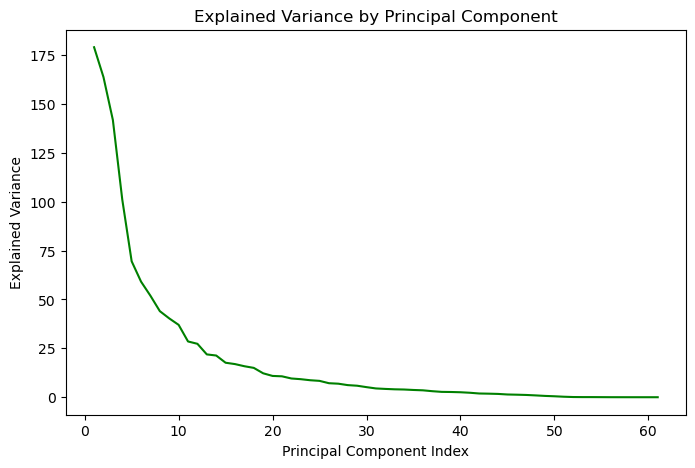

In [124]:
X = digits.data

# maximal number of components equals the rank of the covariance matrix
pca_full = PCA(n_components=61, random_state=12)
pca_full.fit(X)

explained_variance = pca_full.explained_variance_

plt.figure(figsize=(8, 5))
plt.plot(range(1, len(explained_variance) + 1), explained_variance, color='green')
plt.xlabel('Principal Component Index')
plt.ylabel('Explained Variance')
plt.title('Explained Variance by Principal Component')
plt.show()

Answer:

* 1. The maximal value of n_components is 61 because the covariance matrix has rank 61, so there are only 61 linearly independent directions of variation in the digit data

* 3. The explained variance decreases because PCA order the principal components from largest variance to smallest variance, so each later component explains less remaining varation than the one before it.

### Now use PCA to find a 2-dim subspace to reconstruct the digits

Here we first perform dimension reduction of our 64-dimensional data. The goal is to reduce the dimension to 2, and we want to use PCA for that. Then we 'reconstruct' the data by finding the approximation to the original image (or vector in 64-dimensional space).  To this end, we find the first two unit eigenvectors of the covariance matrix (i.e. the first two principal component loading vectors) and use them together with the correponding principal component scores to reconstruct the digits image. Formally, if $w_1,\ldots,w_p$ denote the principal component loading vectors (and recall that they form an orthogonal basis of unit eigenvectors of the covariance matrix), then each $p$-dimensional data vector $X$ can be written as

$$X = \sum_{j=1}^p w_j Z_{j}$$

where $Z_{j} = \langle w_j,X \rangle$ is the projection score of $X$ when projected on $w_j$. These vectors of projection scores (i.e. the principal components) are exactly the projections of the data onto the corresponding eigenvectors of the covariance matrix. The 'reconstruction' $X^{(k)}_{\rm inv}$ of $X$ based on $k \le p$ principal component axis is

$$X^{(k)}_{\rm inv} = \sum_{j=1}^k w_j Z_{j}.$$

The index 'inv' stands for *inverse* (so we try to approximate the inverse map: from the loadings (eigenvectors) and principal components (or projection scores) back to the data. You don't have to implement the reconstruction yourself. Just use the corresponding recommended function that comes with the PCA function from scikit-learn (sklearn).

Recommend functions: PCA, transform, inverse_transform

Notes_VarExplanation:

* X_new: the first 2 principal component scores for each image
* X_inv: the reconstruction back in the original 64-dimensional space

In [125]:
# X_new is a list of lists which contains the first two PC for each digit image
# X_inv is the reconstructed digit image with the same shape as X
# set the random_state = 12 for the PCA function(!) this is important for your grade.

# your code starts here
X = digits.data

pca_2 = PCA(n_components=2, random_state=12)
X_new = pca_2.fit_transform(X)
X_inv = pca_2.inverse_transform(X_new)
# end here

### Plot each digit (elements in X_new) with different color labels

Make a scatter plot of the first two pc scores and mark each point with different color that corresponds to its label, 0~9.

Recommended functions: plt.scatter

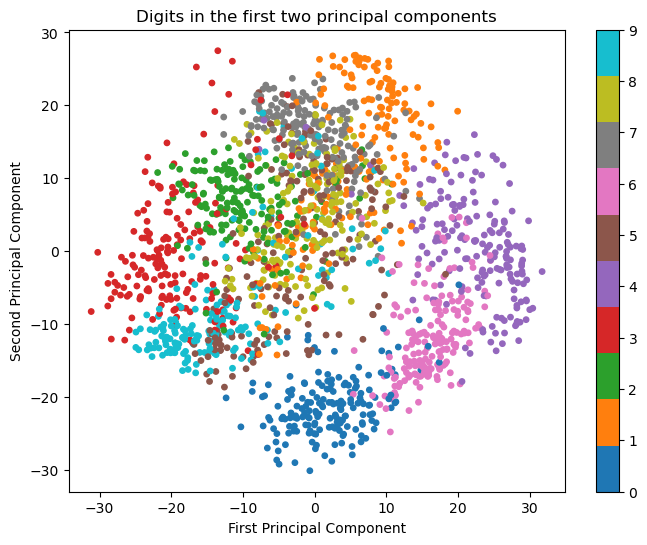

In [126]:
## your code starts here
plt.figure(figsize=(8, 6))
plt.scatter(X_new[:, 0], X_new[:, 1], c=digits.target, cmap='tab10', s=15)
plt.xlabel('First Principal Component')
plt.ylabel('Second Principal Component')
plt.title('Digits in the first two principal components')
plt.colorbar()
plt.show()
## end here

### Write a function to do a side-by-side plot of the original digit and the reconstructed digit

The the left subplot is the reconstructed (or the compressed) digit, and the right subplot is the original digit. 'index' is the index of the image we want to reconstruct and plot.

In [127]:
def plot_digits(index: int):
    """
    the left part is the compressed digit, the right part is the original digit
    """
    ## your code starts here
    plt.figure(figsize=(6, 3))

    # left: reconstructed digit from the 2D PCA representation
    plt.subplot(1, 2, 1)
    plt.imshow(X_inv[index].reshape(8, 8), cmap='gray')
    plt.title('Reconstructed')
    plt.axis('off')

    # right: original digit
    plt.subplot(1, 2, 2)
    plt.imshow(digits.data[index].reshape(8, 8), cmap='gray')
    plt.title('Original')
    plt.axis('off')

    plt.tight_layout()
    plt.show()
    ## end here

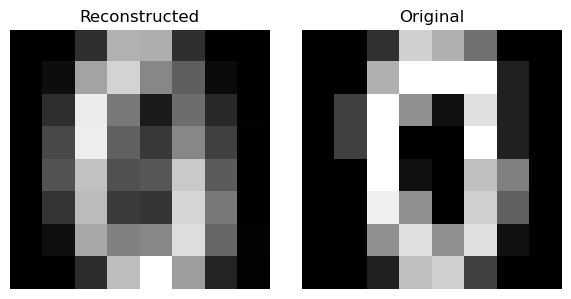

In [128]:
plot_digits(20)

## <font color="Red"> Run the following code.</font> (do not change the code!)

In [129]:
X_inv[0]

array([ 0.00000000e+00,  1.10626731e-01,  4.44191091e+00,  1.18063218e+01,
        1.07493162e+01,  3.39833538e+00,  5.09913257e-02, -4.20292519e-02,
        2.49610314e-03,  1.69701627e+00,  1.19740913e+01,  1.16788045e+01,
        8.38141353e+00,  7.34547153e+00,  6.11222791e-01,  3.14124167e-02,
        1.94499450e-03,  3.47286480e+00,  1.40160403e+01,  5.68604587e+00,
        2.51564937e+00,  7.91668154e+00,  2.32198140e+00,  4.03119293e-02,
       -2.15809063e-04,  4.02956747e+00,  1.27804315e+01,  5.93137932e+00,
        4.63725710e+00,  8.66603199e+00,  3.63836320e+00,  2.81493738e-03,
        0.00000000e+00,  4.01351033e+00,  9.05748107e+00,  3.10220263e+00,
        4.12475646e+00,  1.22384926e+01,  5.60232370e+00,  0.00000000e+00,
        1.34385152e-02,  2.53046936e+00,  9.27133983e+00,  1.19509206e+00,
        9.92215935e-01,  1.33325824e+01,  8.13131715e+00,  5.34711349e-02,
        1.24618620e-02,  9.39578615e-01,  1.08402534e+01,  6.87893752e+00,
        7.21199854e+00,  

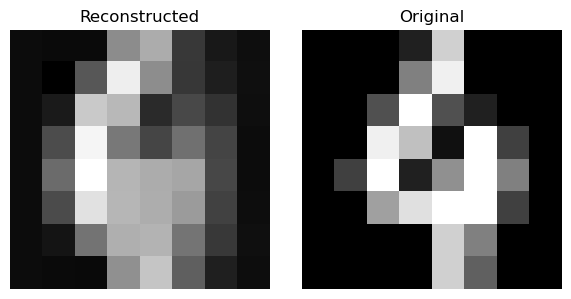

In [130]:
plot_digits(100)

# <font color="blue"> Submission Instructions</font>

1. Click the Save button at the top of the Jupyter Notebook.
2. Select Cell -> All Output -> Clear. This will clear all the outputs from all cells (but will keep the content of the cells).
3. Select Cell -> Run All. This will run all the cells in order, and will take several minutes. <font color='red'>You will not get any grade if you don't follow this step strictly.</font>
4. Once you've rerun everything, select File -> Download .ipynb
5. Upload your .ipynb file to Homework 1 tab on Gradescope. 
6. Also upload the scan of your solutions to Part I to Homework 1 tab on Gradescope.

   You may submit as many times as you like before the submission deadline.
